# Smart Ad Ranker — исследовательский ноутбук

CTR-предсказание, семантический поиск объявлений, RTB-аукцион, оптимизация ставок.

**Датасет:** [Avazu CTR Prediction](https://www.kaggle.com/c/avazu-ctr-prediction)

---
## Содержание
1. [Установка и импорты](#1)
2. [Загрузка данных и EDA](#2)
3. [Препроцессинг](#3)
4. [DeepFM — обучение CTR-модели](#4)
5. [Оценка и Platt Scaling](#5)
6. [Two-Tower — файнтюн энкодера запросов](#6)
7. [FAISS — семантический поиск](#7)
8. [Auction Simulator](#8)
9. [Bid Optimizer](#9)
10. [Gradio Demo](#10)
11. [Итоги](#11)


## 1. Установка и импорты <a id='1'></a>

In [1]:
!pip install -q torch transformers sentence-transformers faiss-cpu \
              pandas pyarrow scikit-learn scipy matplotlib gradio tqdm


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.2/12.2 MB 83.5 MB/s eta 0:00:00:00:01:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.2/18.2 MB 76.3 MB/s eta 0:00:00:00:0100:01
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
dask-cuda 26.2.0 requires cuda-core==0.3.*, but you have cuda-core 1.0.1 which is incompatible.
dask-cuda 26.2.0 requires numba-cuda<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
distributed-ucxx-cu12 0.48.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
cuml-cu12 26.2.0 requires numba<0.62.0,>=0.60.0, but you have numba 0.65.1 which is incompatible.
cuml-cu12 26.2.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
ucxx-cu12 0.48.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incom

In [2]:
import os, pickle, hashlib, warnings
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset, Dataset
from torch.optim import Adam, AdamW
from torch.optim.lr_scheduler import ReduceLROnPlateau
from pathlib import Path
from sklearn.metrics import roc_auc_score, log_loss
from sklearn.calibration import calibration_curve
from sklearn.decomposition import PCA
from scipy.stats import lognorm
from dataclasses import dataclass
import matplotlib
import matplotlib.pyplot as plt

# DejaVu Sans поддерживает кириллицу на большинстве систем (Colab, Ubuntu)
matplotlib.rcParams['font.family'] = 'DejaVu Sans'
matplotlib.rcParams['figure.dpi'] = 110
warnings.filterwarnings('ignore')

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Устройство: {DEVICE}')
torch.manual_seed(42)
np.random.seed(42)


Устройство: cuda


## 2. Загрузка данных и EDA <a id='2'></a>



In [3]:
#  Путь к файлу 
DATA_PATH = '/kaggle/input/competitions/avazu-ctr-prediction/train.gz'

# Для быстрой проверки: 2M строк (~1 день)
# Для нескольких дней: 10M+ строк (или None = все 40M)
NROWS = 10_000_000

df_raw = pd.read_csv(DATA_PATH, nrows=NROWS)
print(f'Загружено: {df_raw.shape}')
df_raw.head(3)


Загружено: (10000000, 24)


,id,click,hour,C1,banner_pos,site_id,site_domain,site_category,app_id,app_domain,...,device_type,device_conn_type,C14,C15,C16,C17,C18,C19,C20,C21
0,1.000009e+18,0,14102100,1005,0,1fbe01fe,f3845767,28905ebd,ecad2386,7801e8d9,...,1,2,15706,320,50,1722,0,35,-1,79
1,1.000017e+19,0,14102100,1005,0,1fbe01fe,f3845767,28905ebd,ecad2386,7801e8d9,...,1,0,15704,320,50,1722,0,35,100084,79
2,1.000037e+19,0,14102100,1005,0,1fbe01fe,f3845767,28905ebd,ecad2386,7801e8d9,...,1,0,15704,320,50,1722,0,35,100084,79


In [4]:
# Базовая статистика
click_rate = df_raw['click'].mean()
print(f'CTR (доля кликов):     {click_rate:.3%}')
print(f'Уникальных site_id:    {df_raw["site_id"].nunique()}')
print(f'Уникальных app_id:     {df_raw["app_id"].nunique()}')
print(f'Уникальных device_id:  {df_raw["device_id"].nunique()}')

# Формат hour: YYMMDDHH — расшифровываем
h = df_raw['hour'].astype(str)
df_raw['_hod'] = h.str[6:8].astype(int)
print(f'Дней в данных:         {h.str[:6].nunique()}')
print(f'Диапазон часов:        {df_raw["_hod"].min()} — {df_raw["_hod"].max()}')


CTR (доля кликов):     16.614%
Уникальных site_id:    3496
Уникальных app_id:     5469
Уникальных device_id:  786741
Дней в данных:         3
Диапазон часов:        0 — 23


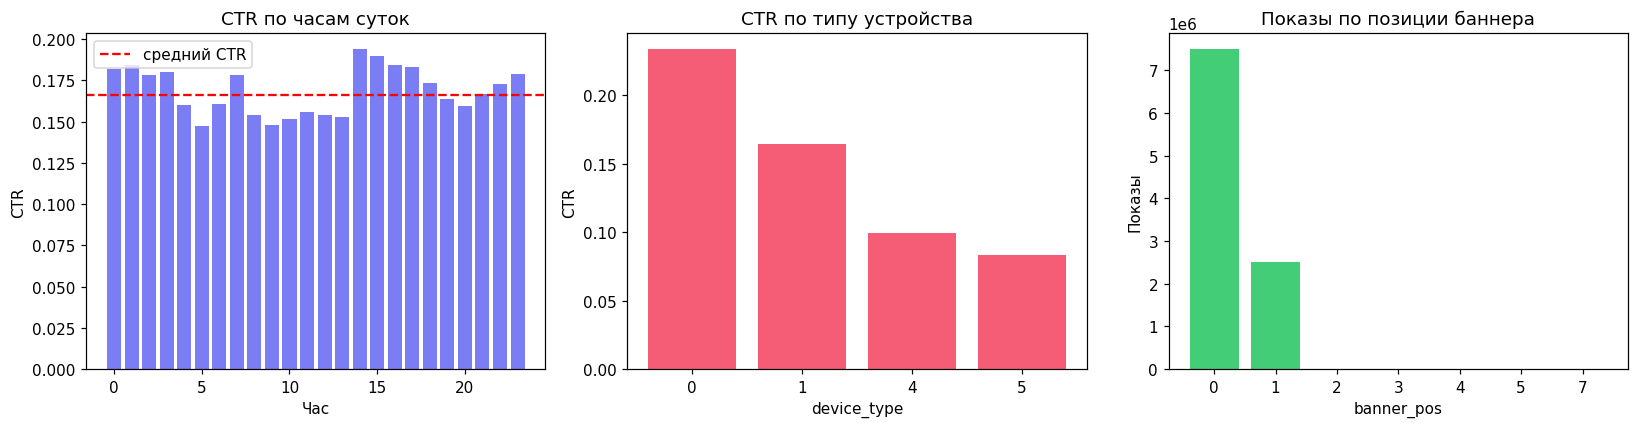

In [5]:
# EDA + графики
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# CTR по часам суток
ctr_hour = df_raw.groupby('_hod')['click'].mean()
axes[0].bar(ctr_hour.index, ctr_hour.values, color='#6366f1', alpha=0.85)
axes[0].axhline(click_rate, color='red', linestyle='--', label='средний CTR')
axes[0].set_title('CTR по часам суток')
axes[0].set_xlabel('Час')
axes[0].set_ylabel('CTR')
axes[0].legend()

# CTR по типу устройства
ctr_dev = df_raw.groupby('device_type')['click'].mean().sort_values(ascending=False)
axes[1].bar(ctr_dev.index.astype(str), ctr_dev.values, color='#f43f5e', alpha=0.85)
axes[1].set_title('CTR по типу устройства')
axes[1].set_xlabel('device_type')
axes[1].set_ylabel('CTR')

# Распределение banner_pos
counts = df_raw['banner_pos'].value_counts().sort_index()
axes[2].bar(counts.index.astype(str), counts.values, color='#22c55e', alpha=0.85)
axes[2].set_title('Показы по позиции баннера')
axes[2].set_xlabel('banner_pos')
axes[2].set_ylabel('Показы')

plt.tight_layout()
plt.show()
df_raw = df_raw.drop(columns=['_hod'])  # убираем временную колонку


## 3. Препроцессинг <a id='3'></a>

- **Темпоральный сплит**: по дням если дней >= 3, иначе по часам внутри дня
- **Frequency encoding**: значения с частотой < min_freq → OOV (индекс 0)
- **Кросс-фичи**: парные взаимодействия
- **Признаки со врменем**: час, день недели, прайм-тайм, выходной


In [6]:
CAT_COLS = [
    'C1', 'banner_pos', 'site_id', 'site_domain', 'site_category',
    'app_id', 'app_domain', 'app_category', 'device_id', 'device_ip',
    'device_model', 'device_type', 'device_conn_type',
    'C14', 'C15', 'C16', 'C17', 'C18', 'C19', 'C20', 'C21',
]
TARGET = 'click'
HASH_BUCKETS = 2**13


def hash_encode(val, n=HASH_BUCKETS):
    # хэш строки в [0, n)
    return int(hashlib.md5(str(val).encode()).hexdigest(), 16) % n


def extract_time_features(df):
    # Извлекаем временные фичи из колонки hour (формат YYMMDDHH)
    df = df.copy()
    h = df['hour'].astype(str)
    df['day_str']     = h.str[:6]               
    df['hour_of_day'] = h.str[6:8].astype(int)  # 0..23
    df['day_of_week'] = h.str[4:6].astype(int) % 7
    df['is_weekend']  = (df['day_of_week'] >= 5).astype(int)
    df['is_peak']     = df['hour_of_day'].isin([8,9,12,13,18,19,20,21]).astype(int)
    return df


def add_cross_features(df):
    df = df.copy()
    df['site_x_banner'] = df.apply(
        lambda r: hash_encode(f"{r['site_id']}_{r['banner_pos']}"), axis=1)
    df['device_x_app'] = df.apply(
        lambda r: hash_encode(f"{r['device_type']}_{r['app_category']}"), axis=1)
    return df


def build_vocab(df, cols, min_freq=10, max_vocab=30_000):
    vocab = {}
    for col in cols:
        freq = df[col].value_counts()
        top  = freq[freq >= min_freq].head(max_vocab).index.tolist()
        vocab[col] = {v: i+1 for i, v in enumerate(top)}
    return vocab


def apply_vocab(df, vocab):
    # Маппинг категорий. Неизвестные значения → 0
    df = df.copy()
    for col, mapping in vocab.items():
        if col in df.columns:
            df[col] = df[col].map(mapping).fillna(0).astype(int)
    return df


In [7]:
# ── Темпоральный сплит ───────────────────────────────────────────────────────
df   = extract_time_features(df_raw)
days = sorted(df['day_str'].unique())
print(f'Дней в данных: {len(days)} -> {days}')

if len(days) >= 3:
    # Несколько дней: train = все кроме 2 последних
    train_df = df[df['day_str'].isin(days[:-2])].copy()
    val_df   = df[df['day_str'].isin(days[-2:-1])].copy()
    test_df  = df[df['day_str'].isin(days[-1:])].copy()
    print('Режим: сплит по дням')

elif len(days) == 2:
    train_df = df[df['day_str'] == days[0]].copy()
    val_df   = df[df['day_str'] == days[1]].copy()
    test_df  = val_df.copy()  # test = val при 2 днях
    print('Режим: 2 дня -> train/val')

else:
    # 1 день -> темпоральный сплит по часам суток
    # Avazu: первый день имеет часы 0..23 -> делим 70/15/15
    hours = sorted(df['hour_of_day'].unique())
    n = len(hours)
    train_h = set(hours[:int(n * 0.70)])
    val_h   = set(hours[int(n * 0.70):int(n * 0.85)])
    test_h  = set(hours[int(n * 0.85):])
    train_df = df[df['hour_of_day'].isin(train_h)].copy()
    val_df   = df[df['hour_of_day'].isin(val_h)].copy()
    test_df  = df[df['hour_of_day'].isin(test_h)].copy()
    print(f'Режим: 1 день -> сплит по часам')
    print(f'  train hours: {sorted(train_h)}')
    print(f'  val   hours: {sorted(val_h)}')
    print(f'  test  hours: {sorted(test_h)}')

print(f'train={len(train_df):,}  val={len(val_df):,}  test={len(test_df):,}')


Дней в данных: 3 -> ['141021', '141022', '141023']
Режим: сплит по дням
train=4,122,995  val=5,337,126  test=539,879


In [8]:
# Кросс-фичи
train_df = add_cross_features(train_df)
val_df   = add_cross_features(val_df)
test_df  = add_cross_features(test_df)

# Словарь только из train (нет утечки из val/test)
vocab = build_vocab(train_df, CAT_COLS)

# Временные фичи
EXTRA_COLS = ['hour_of_day', 'day_of_week', 'is_weekend', 'is_peak']
for col in EXTRA_COLS:
    mx = int(df[col].max()) + 1
    vocab[col] = {v: v for v in range(mx)}

# Кросс-фичи
CROSS_COLS   = ['site_x_banner', 'device_x_app']
ALL_FEAT_COLS = CAT_COLS + EXTRA_COLS + CROSS_COLS

train_df = apply_vocab(train_df, vocab)
val_df   = apply_vocab(val_df,   vocab)
test_df  = apply_vocab(test_df,  vocab)

# Размеры словарей для таблицы эмбеддингов DeepFM 
field_dims = []
for c in CAT_COLS + EXTRA_COLS:
    field_dims.append(max(vocab[c].values()) + 2 if vocab[c] else 2)
for _ in CROSS_COLS:
    field_dims.append(HASH_BUCKETS)  # кросс-фичи -> HASH_BUCKETS бакетов

print(f'Признаков: {len(ALL_FEAT_COLS)}')
print(f'  CAT: {len(CAT_COLS)}, EXTRA: {len(EXTRA_COLS)}, CROSS: {len(CROSS_COLS)}')
print(f'Суммарный vocab: {sum(field_dims):,}')


Признаков: 27
  CAT: 21, EXTRA: 4, CROSS: 2
Суммарный vocab: 65,107


## 4. DeepFM — обучение CTR-модели <a id='4'></a>

 FM (парные взаимодействия) + MLP (нелинейные паттерны).


In [9]:
class FMLayer(nn.Module):
    # Слой факторизационных машин второго порядка
    def forward(self, x):          # x: (B, F, E)
        sq_sum = x.sum(dim=1) ** 2
        sum_sq = (x ** 2).sum(dim=1)
        return 0.5 * (sq_sum - sum_sq).sum(dim=1, keepdim=True)  # (B, 1)


class MLP(nn.Module):
    # MLP для Deep-части DeepFM
    def __init__(self, in_dim, hidden, dropout=0.2):
        super().__init__()
        layers = []
        for h in hidden:
            layers += [nn.Linear(in_dim, h), nn.BatchNorm1d(h),
                       nn.ReLU(), nn.Dropout(dropout)]
            in_dim = h
        layers.append(nn.Linear(in_dim, 1))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)


class DeepFM(nn.Module):
    def __init__(self, field_dims, embed_dim=16, hidden=(256, 256), dropout=0.2):
        super().__init__()
        self.num_fields = len(field_dims)
        # Общая таблица эмбеддингов для FM и MLP
        self.embedding = nn.Embedding(sum(field_dims), embed_dim, padding_idx=0)
        self.register_buffer('offsets', torch.tensor(
            [0, *torch.cumsum(torch.tensor(field_dims[:-1]), 0).tolist()]
        ))
        self.fm   = FMLayer()
        self.mlp  = MLP(self.num_fields * embed_dim, list(hidden), dropout)
        self.bias = nn.Parameter(torch.zeros(1))
        nn.init.xavier_uniform_(self.embedding.weight)

    def forward(self, x):
        x   = x + self.offsets
        emb = self.embedding(x)                          # (B, F, E)
        out = self.fm(emb) + self.mlp(emb.view(x.size(0), -1)) + self.bias
        return out.squeeze(1)                            # (B,) логиты

    def predict_proba(self, x):
        return torch.sigmoid(self.forward(x))


In [10]:
def make_loader(df, feat_cols, target, batch_size, shuffle=True):
    X = torch.tensor(df[feat_cols].values, dtype=torch.long)
    y = torch.tensor(df[target].values,    dtype=torch.float)
    return DataLoader(TensorDataset(X, y), batch_size=batch_size,
                      shuffle=shuffle, num_workers=0)


def evaluate(model, loader):
    # AUC и LogLoss на произвольном загрузчике
    model.eval()
    preds, labels = [], []
    with torch.no_grad():
        for X, y in loader:
            p = model.predict_proba(X.to(DEVICE)).cpu().numpy()
            preds.extend(p)
            labels.extend(y.numpy())
    p, l = np.array(preds), np.array(labels)
    return {'auc': roc_auc_score(l, p), 'logloss': log_loss(l, p),
            'preds': p, 'labels': l}


BATCH  = 2048
EPOCHS = 2   # чтоб не было переобучения
LR     = 1e-3

train_loader = make_loader(train_df, ALL_FEAT_COLS, TARGET, BATCH)
val_loader   = make_loader(val_df,   ALL_FEAT_COLS, TARGET, BATCH * 2, shuffle=False)
test_loader  = make_loader(test_df,  ALL_FEAT_COLS, TARGET, BATCH * 2, shuffle=False)

model = DeepFM(field_dims, embed_dim=16, hidden=(256, 256)).to(DEVICE)
print(f'Параметров модели: {sum(p.numel() for p in model.parameters()):,}')


Параметров модели: 1,219,634


In [11]:
optimizer = Adam(model.parameters(), lr=LR, weight_decay=1e-6)

# Снижаем LR когда val AUC перестаёт расти
scheduler = ReduceLROnPlateau(
    optimizer,
    mode='max',
    patience=1,
    factor=0.5
)

criterion = nn.BCEWithLogitsLoss()

train_losses, val_aucs = [], []
best_auc = 0.0

Path('checkpoints').mkdir(exist_ok=True)

print(f'{"Эпоха":>6}  {"Train Loss":>11}  {"Val AUC":>8}  {"Val LogLoss":>11}')
print('-' * 45)

for epoch in range(EPOCHS):

    model.train()
    ep_loss, steps = 0.0, 0

    for X, y in train_loader:
        X, y = X.to(DEVICE), y.to(DEVICE)

        loss = criterion(model(X), y)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        ep_loss += loss.item()
        steps += 1

    avg_loss = ep_loss / steps

    # validation
    m = evaluate(model, val_loader)

    # scheduler
    old_lr = optimizer.param_groups[0]['lr']
    scheduler.step(m['auc'])
    new_lr = optimizer.param_groups[0]['lr']

    if new_lr < old_lr:
        print(f'  LR снижен: {old_lr:.2e} -> {new_lr:.2e}')

    # history
    train_losses.append(avg_loss)
    val_aucs.append(m['auc'])

    print(
        f'{epoch+1:>6}  '
        f'{avg_loss:>11.4f}  '
        f'{m["auc"]:>8.4f}  '
        f'{m["logloss"]:>11.4f}'
    )

    # save best model
    if m['auc'] > best_auc:
        best_auc = m['auc']

        torch.save(
            {
                'state': model.state_dict(),
                'field_dims': field_dims,
                'all_feat_cols': ALL_FEAT_COLS
            },
            'checkpoints/deepfm.pt'
        )

        print(f'  -> сохранён (auc={best_auc:.4f})')

 Эпоха   Train Loss   Val AUC  Val LogLoss
---------------------------------------------
     1       0.3971    0.7478       0.3829
  -> сохранён (auc=0.7478)
     2       0.3860    0.7466       0.3854


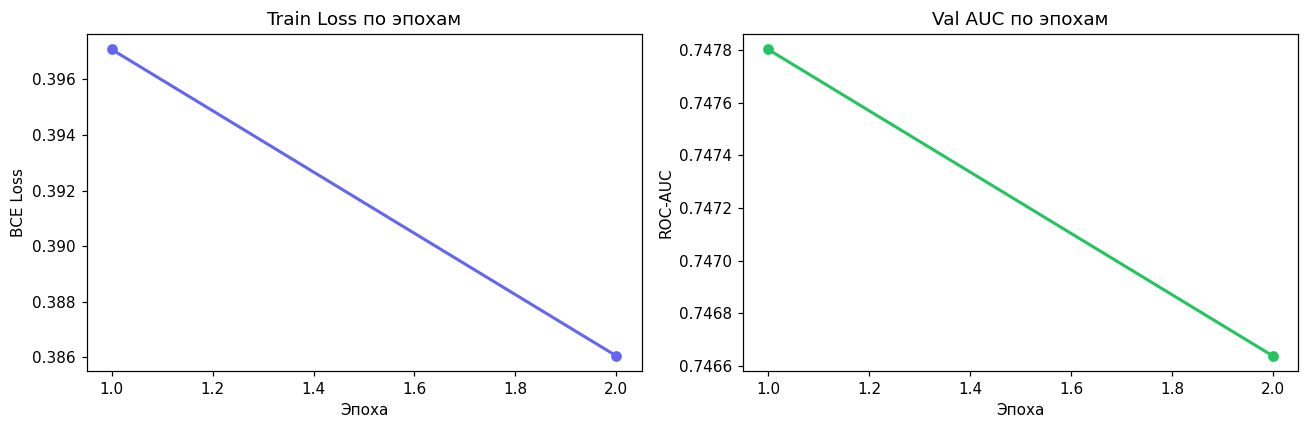

In [12]:
#  Кривые обучения
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.plot(range(1, EPOCHS+1), train_losses, 'o-', color='#6366f1', lw=2)
ax1.set_title('Train Loss по эпохам'); ax1.set_xlabel('Эпоха'); ax1.set_ylabel('BCE Loss')
ax2.plot(range(1, EPOCHS+1), val_aucs, 'o-', color='#22c55e', lw=2)
ax2.set_title('Val AUC по эпохам'); ax2.set_xlabel('Эпоха'); ax2.set_ylabel('ROC-AUC')
plt.tight_layout(); plt.show()


## 5. Оценка и Platt Scaling <a id='5'></a>

Для CPA-стратегий критична калибровка: предсказанная вероятность должна совпадать с реальной.
**Platt Scaling**: sigmoid(a * logit + b) поверх заморожённой модели.


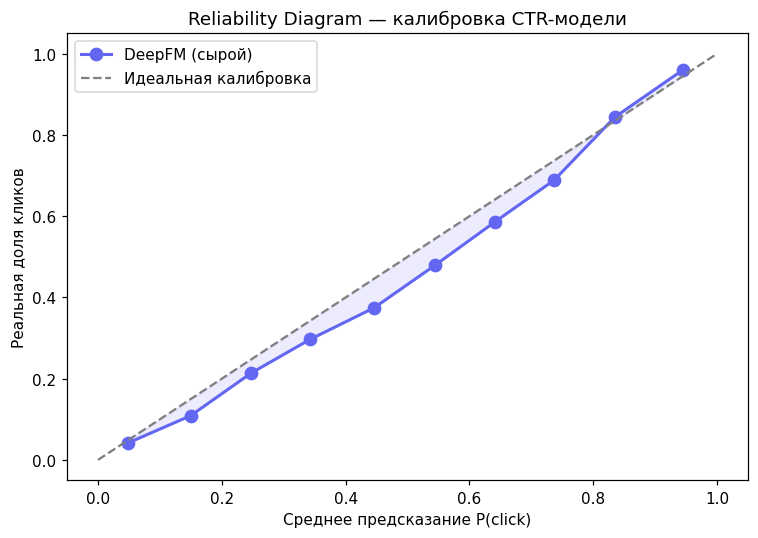

Val AUC:     0.7466
Val LogLoss: 0.3854


In [13]:
val_m = evaluate(model, val_loader)
prob_true, prob_pred = calibration_curve(val_m['labels'], val_m['preds'], n_bins=10)

fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(prob_pred, prob_true, 'o-', color='#6366f1', lw=2, ms=8, label='DeepFM (сырой)')
ax.plot([0,1],[0,1], '--', color='gray', lw=1.5, label='Идеальная калибровка')
ax.fill_between(prob_pred, prob_pred, prob_true, alpha=0.12, color='#6366f1')
ax.set_xlabel('Среднее предсказание P(click)')
ax.set_ylabel('Реальная доля кликов')
ax.set_title('Reliability Diagram — калибровка CTR-модели')
ax.legend(); plt.tight_layout(); plt.show()
print(f'Val AUC:     {val_m["auc"]:.4f}')
print(f'Val LogLoss: {val_m["logloss"]:.4f}')


LogLoss ДО  Platt: 0.3854
LogLoss ПОСЛЕ Platt: 0.3817


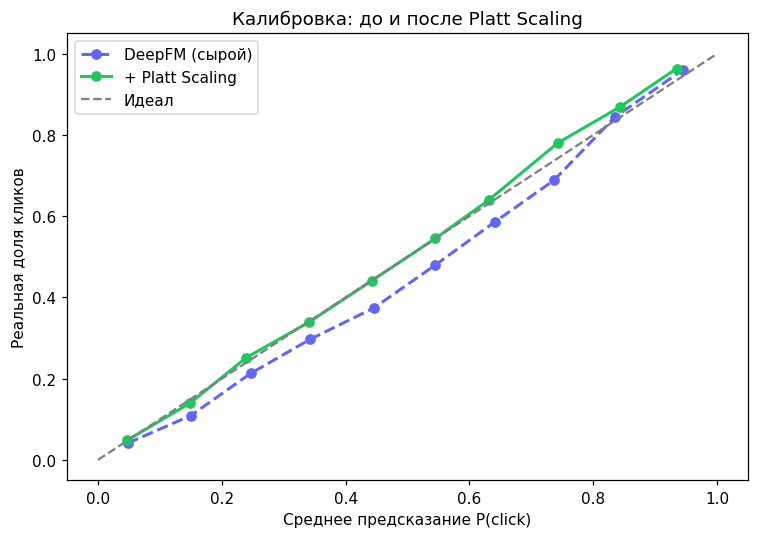

In [14]:
class PlattCalibrator(nn.Module):
    # Двухпараметрическая калибровка: sigmoid(a * logit + b)
    def __init__(self):
        super().__init__()
        self.a = nn.Parameter(torch.ones(1))
        self.b = nn.Parameter(torch.zeros(1))

    def forward(self, logits):
        return torch.sigmoid(self.a * logits + self.b)


# Собираем логиты на val (модель заморожена)
model.eval()
all_logits, all_labels = [], []
with torch.no_grad():
    for X, y in val_loader:
        all_logits.append(model(X.to(DEVICE)).cpu())
        all_labels.append(y)

logits_t = torch.cat(all_logits)
labels_t = torch.cat(all_labels)

calibrator = PlattCalibrator()
cal_opt = Adam(calibrator.parameters(), lr=0.01)
for _ in range(300):
    cal_opt.zero_grad()
    F.binary_cross_entropy(calibrator(logits_t), labels_t).backward()
    cal_opt.step()

cal_preds = calibrator(logits_t).detach().numpy()
print(f'LogLoss ДО  Platt: {log_loss(labels_t.numpy(), val_m["preds"]):.4f}')
print(f'LogLoss ПОСЛЕ Platt: {log_loss(labels_t.numpy(), cal_preds):.4f}')

pt2, pp2 = calibration_curve(labels_t.numpy(), cal_preds, n_bins=10)
fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(prob_pred, prob_true, 'o--', color='#6366f1', lw=2, label='DeepFM (сырой)')
ax.plot(pp2, pt2,             'o-',  color='#22c55e', lw=2, label='+ Platt Scaling')
ax.plot([0,1],[0,1], '--', color='gray', label='Идеал')
ax.set_xlabel('Среднее предсказание P(click)')
ax.set_ylabel('Реальная доля кликов')
ax.set_title('Калибровка: до и после Platt Scaling')
ax.legend(); plt.tight_layout(); plt.show()


## 6. Two-Tower — файнтюн энкодера запросов <a id='6'></a>

**Query Tower**: `paraphrase-multilingual-MiniLM-L12-v2` (pretrained) + проекционная голова.  
**Ad Tower**: Embedding + MLP по категориальным признакам объявления.  

**Обучение**: NT-Xent лосс, in-batch negatives.  
Позитивная пара = (синтетический запрос, кликнутое объявление из той же категории).


In [15]:
from transformers import AutoTokenizer, AutoModel

# Синтетические запросы по категории приложения
CATEGORY_QUERIES = {
    '0f2161f8': ['купить кроссовки', 'обувь со скидкой', 'заказать кеды'],
    'f028772b': ['смартфон акция', 'купить телефон', 'лучший телефон'],
    '50e219e0': ['дешевые авиабилеты', 'забронировать отель', 'туры онлайн'],
    '28905ebd': ['игровой ноутбук', 'видеокарта купить', 'pc для игр'],
    '04d2e4c7': ['доставка еды', 'заказать пиццу', 'ресторан рядом'],
}
DEFAULT_Q = ['скидки сегодня', 'купить онлайн', 'акция магазин']


def synth_query(row):
    # Комбинируем site_category + device_type + hour
    device = {0: 'мобильный', 1: 'планшет', 4: 'телефон'}.get(row['device_type'], 'устройство')
    hour = int(str(row['hour'])[6:8])
    time = 'утром' if hour < 12 else ('вечером' if hour > 18 else 'днём')
    
    templates = [
        f"купить {row['app_category']} {time}",
        f"скидки {row['site_category']} на {device}",
        f"заказать {row['app_category']} онлайн",
    ]
    return np.random.choice(templates)


TOWER_MODEL = 'sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2'
tokenizer   = AutoTokenizer.from_pretrained(TOWER_MODEL)
print(f'Токенизатор загружен: {TOWER_MODEL}')


config.json:   0%|          | 0.00/645 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/526 [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/9.08M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

Токенизатор загружен: sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2


In [17]:
class TwoTowerDataset(Dataset):
    # Датасет позитивных пар (запрос, кликнутое объявление)
    def __init__(self, df, feat_cols):
        clicked = df[df['click'] == 1].reset_index(drop=True)
        
        self.queries  = [synth_query(row) for _, row in clicked.iterrows()]
        self.ad_feats = clicked[feat_cols].values.astype(np.int64)

    def __len__(self):
        return len(self.queries)

    def __getitem__(self, i):
        return self.queries[i], self.ad_feats[i]


def collate_tower(batch):
    queries, feats = zip(*batch)
    return list(queries), torch.tensor(np.stack(feats), dtype=torch.long)


class QueryEncoder(nn.Module):
    # MiniLM + проекционная голова
    def __init__(self, proj_dim=64):
        super().__init__()
        self.encoder = AutoModel.from_pretrained(TOWER_MODEL)
        hidden       = self.encoder.config.hidden_size  # 384 у MiniLM
        self.proj    = nn.Sequential(nn.Linear(hidden, proj_dim), nn.LayerNorm(proj_dim))

    def mean_pool(self, out, mask):
        # Mean pooling с учётом маски паддинга
        m = mask.unsqueeze(-1).float()
        return (out * m).sum(1) / m.sum(1).clamp(min=1e-9)

    def forward(self, input_ids, attention_mask):
        out    = self.encoder(input_ids=input_ids, attention_mask=attention_mask)
        pooled = self.mean_pool(out.last_hidden_state, attention_mask)
        return F.normalize(self.proj(pooled), dim=-1)  # L2-нормализация


class AdEncoder(nn.Module):
    # Эмбеддинг + MLP для признаков объявления
    def __init__(self, field_dims, embed_dim=16, proj_dim=64):
        super().__init__()
        self.emb = nn.Embedding(sum(field_dims), embed_dim, padding_idx=0)
        self.register_buffer('offsets', torch.tensor(
            [0, *torch.cumsum(torch.tensor(field_dims[:-1]), 0).tolist()]
        ))
        in_dim   = len(field_dims) * embed_dim
        self.mlp = nn.Sequential(
            nn.Linear(in_dim, 128), nn.ReLU(),
            nn.Linear(128, proj_dim), nn.LayerNorm(proj_dim)
        )

    def forward(self, x):
        emb = self.emb(x + self.offsets).view(x.size(0), -1)
        return F.normalize(self.mlp(emb), dim=-1)


In [18]:
PROJ_DIM     = 64
TOWER_BATCH  = 128
TOWER_EPOCHS = 6   # рекомендуется 5+ для хорошего качества

q_enc = QueryEncoder(proj_dim=PROJ_DIM).to(DEVICE)
a_enc = AdEncoder(field_dims, embed_dim=16, proj_dim=PROJ_DIM).to(DEVICE)

temperature = nn.Parameter(torch.tensor(0.07, device=DEVICE))

tower_ds     = TwoTowerDataset(train_df, ALL_FEAT_COLS)
tower_loader = DataLoader(tower_ds, batch_size=TOWER_BATCH, shuffle=True,
                          collate_fn=collate_tower, num_workers=0)

# Раздельные LR
tower_opt = AdamW([
    {'params': q_enc.encoder.parameters(), 'lr': 3e-6},
    {'params': q_enc.proj.parameters(),    'lr': 3e-5},
    {'params': a_enc.parameters(),         'lr': 3e-5},
    {'params': [temperature],              'lr': 1e-3},
])


def nt_xent_loss(q, a, temp):
    B      = q.size(0)
    logits = (q @ a.T) / temp.clamp(min=0.01)  # (B, B) матрица сходств
    labels = torch.arange(B, device=q.device)  # диагональ = позитивные пары
    return (F.cross_entropy(logits, labels) + F.cross_entropy(logits.T, labels)) / 2


print('Fine-tuning Two-Tower...')
for epoch in range(TOWER_EPOCHS):
    q_enc.train(); a_enc.train()
    total = 0.0
    for step, (queries, ad_feats) in enumerate(tower_loader):
        ad_feats = ad_feats.to(DEVICE)
        enc = tokenizer(queries, padding=True, truncation=True,
                        max_length=32, return_tensors='pt')
        enc = {k: v.to(DEVICE) for k, v in enc.items()}

        q_emb = q_enc(enc['input_ids'], enc['attention_mask'])
        a_emb = a_enc(ad_feats)
        loss  = nt_xent_loss(q_emb, a_emb, temperature)

        tower_opt.zero_grad(); loss.backward()
        nn.utils.clip_grad_norm_(
            list(q_enc.parameters()) + list(a_enc.parameters()), 1.0)
        tower_opt.step()
        total += loss.item()

        
    print(f'Эпоха {epoch+1}  avg_loss={total/len(tower_loader):.4f}')

torch.save({'q_enc': q_enc.state_dict(), 'a_enc': a_enc.state_dict(),
            'field_dims': field_dims}, 'checkpoints/two_tower.pt')
print('Two-Tower -> checkpoints/two_tower.pt')


model.safetensors:   0%|          | 0.00/471M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Fine-tuning Two-Tower...
Эпоха 1  avg_loss=3.6598
Эпоха 2  avg_loss=3.5364
Эпоха 3  avg_loss=3.5217
Эпоха 4  avg_loss=3.5161
Эпоха 5  avg_loss=3.5130
Эпоха 6  avg_loss=3.5109
Two-Tower -> checkpoints/two_tower.pt


## 7. FAISS — семантический поиск объявлений <a id='7'></a>

Офлайн строим индекс из эмбеддингов объявлений 


In [19]:
import faiss
import pickle
import torch
import numpy as np

INDEX_N = min(5000, len(val_df))


sample_df = val_df[ALL_FEAT_COLS].sample(INDEX_N, random_state=42).reset_index(drop=True)


def build_ad_text(row):
    return (
        f"site_category={row['site_category']} | "
        f"app_category={row['app_category']} | "
        f"site_domain={row['site_domain']} | "
        f"app_domain={row['app_domain']} | "
        f"banner_pos={row['banner_pos']} | "
        f"device_type={row['device_type']} | "
        f"device_model={row['device_model']}"
    )

ad_map = []
for i, row in sample_df.iterrows():
    ad_map.append({
        "faiss_idx": int(i),
        "text": build_ad_text(row),
        "site_category": int(row["site_category"]),
        "app_category": int(row["app_category"]),
        "site_domain": int(row["site_domain"]),
        "app_domain": int(row["app_domain"]),
        "banner_pos": int(row["banner_pos"]),
        "device_type": int(row["device_type"]),
        "device_model": int(row["device_model"]),
    })

ad_feats_np = sample_df.values.astype(np.int64)

# Эмбеддинги
a_enc.eval()
all_embs = []
with torch.no_grad():
    for start in range(0, INDEX_N, 256):
        chunk = torch.tensor(ad_feats_np[start:start + 256], dtype=torch.long).to(DEVICE)
        all_embs.append(a_enc(chunk).cpu().numpy())

embeddings = np.vstack(all_embs).astype("float32")

# FAISS
dim = embeddings.shape[1]
index = faiss.IndexFlatIP(dim)
index.add(embeddings)
print(f"FAISS-индекс: {index.ntotal} векторов, dim={dim}")

# Сохраняем mapping рядом с индексом
with open("ad_map.pkl", "wb") as f:
    pickle.dump(ad_map, f, protocol=pickle.HIGHEST_PROTOCOL)

faiss.write_index(index, "ads_faiss.index")
print("Сохранил ads_faiss.index и ad_map.pkl")

FAISS-индекс: 5000 векторов, dim=64
Сохранил ads_faiss.index и ad_map.pkl


In [21]:
def semantic_search(query_text, top_k=5):
    # Ищем top_k объявлений по текстовому запросу
    q_enc.eval()
    enc = tokenizer([query_text], padding=True, truncation=True,
                    max_length=32, return_tensors='pt')
    enc = {k: v.to(DEVICE) for k, v in enc.items()}
    with torch.no_grad():
        q_emb = q_enc(enc['input_ids'], enc['attention_mask']).cpu().numpy().astype('float32')

    scores, indices = index.search(q_emb, top_k)
    print(f'Запрос: "{query_text}"')
    print(f'{"#":<4} {"Сходство":>9}  {"site_cat":>10}  {"app_cat":>10}  {"баннер":>6}  {"устр":>4}')
    print('-' * 52)
    for rank, (score, idx) in enumerate(zip(scores[0], indices[0]), 1):
        m = ad_meta[idx]
        print(f'{rank:<4} {score:>9.4f}  {str(m["site_category"]):>10}  '
              f'{str(m["app_category"]):>10}  {m["banner_pos"]:>6}  {m["device_type"]:>4}')


for q in ['купить кроссовки', 'cheap flights booking', 'best gaming laptop', 'заказать еду']:
    semantic_search(q, top_k=4)
    print()


Запрос: "купить кроссовки"
#     Сходство    site_cat     app_cat  баннер  устр
----------------------------------------------------
1       0.4216           1           3       1     1
2       0.4192           1           3       1     1
3       0.4048           1           1       3     1
4       0.3866           1          10       1     1

Запрос: "cheap flights booking"
#     Сходство    site_cat     app_cat  баннер  устр
----------------------------------------------------
1       0.3264           2           1       2     1
2       0.3256           2           1       2     1
3       0.3243           2           1       2     1
4       0.3225           2           1       2     1

Запрос: "best gaming laptop"
#     Сходство    site_cat     app_cat  баннер  устр
----------------------------------------------------
1       0.3882           7           1       2     1
2       0.3804           3           1       1     1
3       0.3775           4           1       1     1
4       0

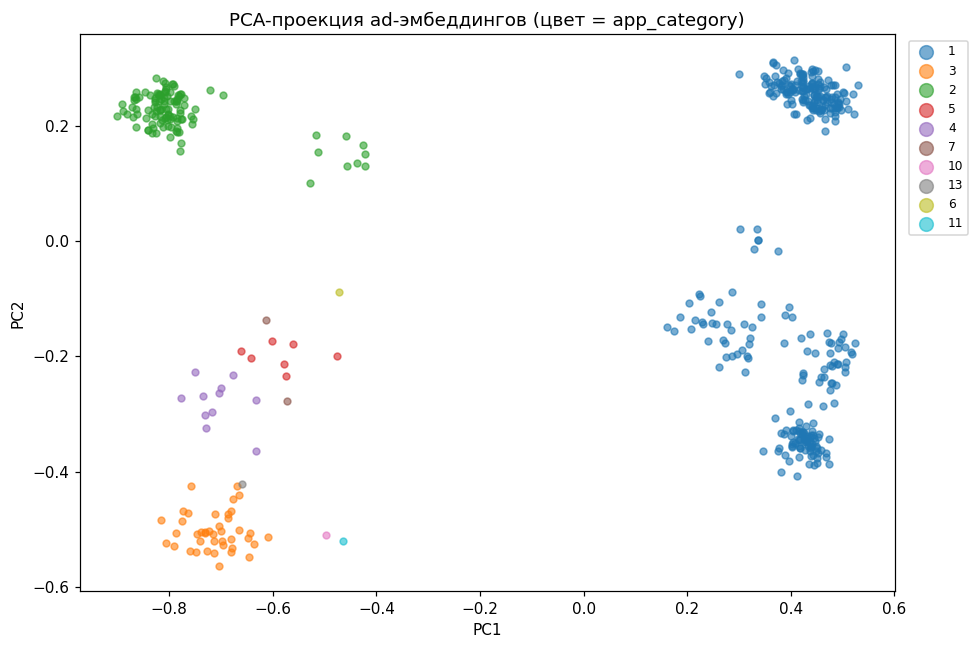

In [22]:
#  PCA-визуализация пространства эмбеддингов 
N_VIS      = min(500, INDEX_N)
categories = [m['app_category'] for m in ad_meta[:N_VIS]]
embs_vis   = embeddings[:N_VIS]

pca = PCA(n_components=2, random_state=42)
xy  = pca.fit_transform(embs_vis)

unique_cats = list(dict.fromkeys(categories))[:10]
colors      = plt.cm.tab10(np.linspace(0, 1, len(unique_cats)))
cat_color   = {c: colors[i] for i, c in enumerate(unique_cats)}

fig, ax = plt.subplots(figsize=(9, 6))
for cat in unique_cats:
    mask = [c == cat for c in categories]
    ax.scatter(xy[mask, 0], xy[mask, 1], label=str(cat)[:8],
               alpha=0.6, s=20, color=cat_color[cat])
ax.set_title('PCA-проекция ad-эмбеддингов (цвет = app_category)')
ax.set_xlabel('PC1'); ax.set_ylabel('PC2')
ax.legend(bbox_to_anchor=(1.01, 1), fontsize=8, markerscale=2)
plt.tight_layout(); plt.show()


## 8. Auction Simulator <a id='8'></a>

**Second-price (Vickrey) аукцион**: победитель платит ставку второго участника.  
**Budget pacing**: ставка модулируется чтобы бюджет расходовался равномерно.


In [23]:
@dataclass
class Advertiser:
    name: str
    daily_budget: float  # дневной бюджет USD
    base_bid: float      # базовая ставка CPM USD
    spent: float = 0.0
    wins: int = 0
    clicks: int = 0
    conversions: int = 0
    seen: int = 0

    @property
    def remaining(self):
        return max(0.0, self.daily_budget - self.spent)

    def effective_bid(self, rng):
        if self.remaining <= 0:
            return 0.0
        # Pacing: снижаем ставку когда бюджет почти исчерпан
        pacing = min(1.0, self.remaining / self.daily_budget * 2)
        # Логнормальный шум — неопределённость ценности конкретного показа
        return self.base_bid * pacing * rng.lognormal(0, 0.08)


def run_simulation(advertisers, n_auctions=50_000, floor=0.1,
                   avg_ctr=0.005, avg_cvr=0.02, seed=42):
    rng = np.random.default_rng(seed)
    for a in advertisers:
        a.spent = a.wins = a.clicks = a.conversions = a.seen = 0
    history = []

    for _ in range(n_auctions):
        bids = {}
        for a in advertisers:
            a.seen += 1
            b = a.effective_bid(rng)
            if b >= floor:
                bids[a.name] = b

        if not bids:
            continue

        sorted_bids = sorted(bids.items(), key=lambda x: x[1], reverse=True)
        winner_name = sorted_bids[0][0]
        # Second-price: победитель платит ставку второго участника
        price_paid  = sorted_bids[1][1] if len(sorted_bids) > 1 else floor

        winner = next(a for a in advertisers if a.name == winner_name)
        cost   = price_paid / 1000.0  # CPM -> стоимость одного показа
        winner.spent += cost
        winner.wins  += 1

        clicked   = rng.random() < avg_ctr
        converted = clicked and (rng.random() < avg_cvr)
        if clicked:   winner.clicks += 1
        if converted: winner.conversions += 1

        history.append({'winner': winner_name, 'cost': cost,
                        'click': int(clicked), 'conv': int(converted)})
    return history


In [24]:
YOUR_BID    = 2.5    # CPM $
YOUR_BUDGET = 100.0  # дневной бюджет $

advertisers = [Advertiser('Вы', daily_budget=YOUR_BUDGET, base_bid=YOUR_BID)]
rng_s = np.random.default_rng(0)
for i in range(5):
    advertisers.append(Advertiser(
        f'Конк_{i+1}',
        daily_budget=rng_s.uniform(50, 200),
        base_bid=rng_s.lognormal(np.log(2.0), 0.4),
    ))

history = run_simulation(advertisers, n_auctions=50_000)

print(f'{"Участник":<12} {"Бюджет":>8}  {"Потрачено":>10}  '
      f'{"Побед":>7}  {"Кликов":>7}  {"Конв":>5}  {"Win%":>7}  {"CPA":>8}')
print('-' * 72)
for a in advertisers:
    wr  = a.wins / max(a.seen, 1)
    cpa = a.spent / a.conversions if a.conversions > 0 else float('inf')
    cpa_s = f'${cpa:.2f}' if cpa < 1e6 else 'inf'
    print(f'{a.name:<12} ${a.daily_budget:>7.0f}  ${a.spent:>9.2f}  '
          f'{a.wins:>7,}  {a.clicks:>7,}  {a.conversions:>5,}  {wr:>7.2%}  {cpa_s:>8}')


Участник       Бюджет   Потрачено    Побед   Кликов   Конв     Win%       CPA
------------------------------------------------------------------------
Вы           $    100  $    29.38   11,986       72      3   23.97%     $9.79
Конк_1       $    146  $     0.03       13        0      0    0.03%       inf
Конк_2       $     56  $     0.64      272        0      0    0.54%       inf
Конк_3       $    172  $     7.38    3,026       15      0    6.05%       inf
Конк_4       $    141  $    87.28   34,703      170      3   69.41%    $29.09
Конк_5       $    132  $     0.00        0        0      0    0.00%       inf


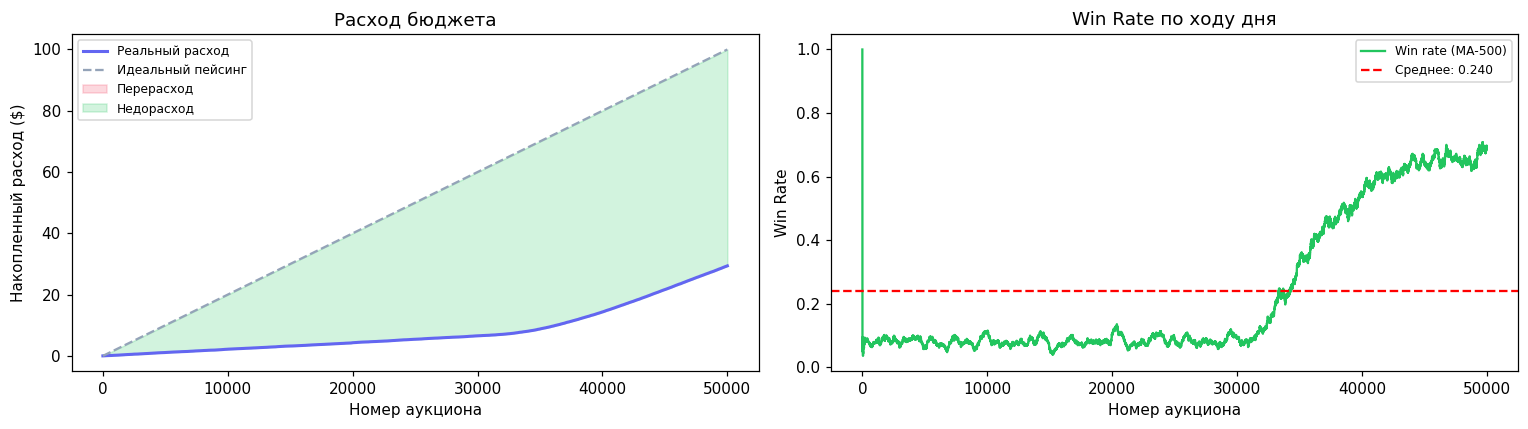

In [25]:
you_costs  = np.array([h['cost'] if h['winner'] == 'Вы' else 0 for h in history])
cum_spend  = np.cumsum(you_costs)
ideal_pace = np.linspace(0, YOUR_BUDGET, len(history))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))

ax1.plot(cum_spend,  color='#6366f1', lw=2, label='Реальный расход')
ax1.plot(ideal_pace, color='#94a3b8', lw=1.5, ls='--', label='Идеальный пейсинг')
ax1.fill_between(range(len(cum_spend)), cum_spend, ideal_pace,
                 where=cum_spend > ideal_pace, alpha=0.2, color='#f43f5e', label='Перерасход')
ax1.fill_between(range(len(cum_spend)), cum_spend, ideal_pace,
                 where=cum_spend < ideal_pace, alpha=0.2, color='#22c55e', label='Недорасход')
ax1.set_title('Расход бюджета')
ax1.set_xlabel('Номер аукциона')
ax1.set_ylabel('Накопленный расход ($)')
ax1.legend(fontsize=8)

your_wins = np.array([1 if h['winner'] == 'Вы' else 0 for h in history], dtype=float)
win_ma    = pd.Series(your_wins).rolling(500, min_periods=1).mean()
ax2.plot(win_ma, color='#22c55e', lw=1.5, label='Win rate (MA-500)')
ax2.axhline(your_wins.mean(), color='red', ls='--',
            label=f'Среднее: {your_wins.mean():.3f}')
ax2.set_title('Win Rate по ходу дня')
ax2.set_xlabel('Номер аукциона')
ax2.set_ylabel('Win Rate')
ax2.legend(fontsize=8)

plt.tight_layout(); plt.show()


## 9. Bid Optimizer <a id='9'></a>

Найти оптимальный CPM-бид, максимизирующий конверсии при `CPA <= target_CPA`.

- **Модель рынка**: цена аукциона ~ LogNormal(mu, sigma)
- **Win rate(bid)** = P(рыночная цена < bid) = CDF логнормального
- **CPA(bid)** = (bid/1000) / (win_rate * CTR * CVR)


In [26]:
def win_rate_curve(bid, market_avg=2.0, market_std=1.0):
    # Win rate как функция ставки при логнормальной модели рынка
    sigma = market_std / market_avg
    mu    = np.log(market_avg) - 0.5 * sigma**2
    return lognorm.cdf(bid, s=sigma, scale=np.exp(mu))


def bid_optimizer(target_cpa, ctr, cvr, market_avg=2.0, market_std=1.0, n=300):
    # Перебираем сетку ставок, выбираем наибольшую при CPA <= target
    max_cpm = target_cpa * ctr * cvr * 1000  # потолок при win_rate=1
    bids    = np.linspace(0.01, max_cpm * 1.5, n)
    wrs     = win_rate_curve(bids, market_avg, market_std)
    exp_cpa = np.where(wrs > 0,
                       (bids / 1000) / (wrs * ctr * cvr + 1e-12),
                       np.inf)
    feasible = bids[exp_cpa <= target_cpa]
    feasible = bids[exp_cpa <= target_cpa]
    if len(feasible) == 0:
        # Цель недостижима — возвращаем бид с минимальным CPA
        opt_bid = bids[np.nanargmin(np.where(np.isinf(exp_cpa), np.nan, exp_cpa))]
        print(f'Target CPA=${target_cpa} недостижим на этом рынке.')
        print(f'Минимальный достижимый CPA = ${np.nanmin(exp_cpa):.2f}')
    else:
        opt_bid = feasible[-1]

    return bids, wrs, exp_cpa, opt_bid, max_cpm


TARGET_CPA = 30.0
CTR        = 0.005
CVR        = 0.02
MARKET_AVG = 2.0

bids, wrs, cpas, opt_bid, max_cpm = bid_optimizer(TARGET_CPA, CTR, CVR, MARKET_AVG)
opt_wr  = win_rate_curve(opt_bid, MARKET_AVG)
opt_cpa = (opt_bid / 1000) / (opt_wr * CTR * CVR + 1e-12)

print(f'Целевой CPA:           ${TARGET_CPA:.2f}')
print(f'Макс. допустимая CPM:  ${max_cpm:.3f}')
print(f'Оптимальная ставка:    ${opt_bid:.3f} CPM')
print(f'Ожидаемый win rate:    {opt_wr:.2%}')
print(f'Ожидаемый CPA:         ${opt_cpa:.2f}')


⚠️  Target CPA=$30.0 недостижим на этом рынке.
   Минимальный достижимый CPA = $32.77
Целевой CPA:           $30.00
Макс. допустимая CPM:  $3.000
Оптимальная ставка:    $2.293 CPM
Ожидаемый win rate:    69.95%
Ожидаемый CPA:         $32.77


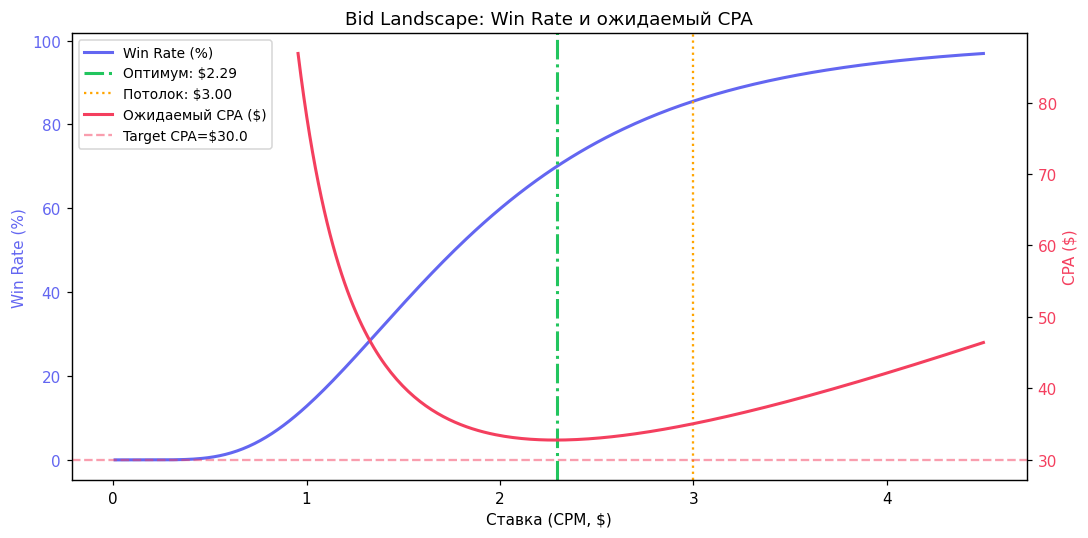

In [27]:
cpas_plot = np.where(cpas > TARGET_CPA * 3, np.nan, cpas)

fig, ax1 = plt.subplots(figsize=(10, 5))
ax2 = ax1.twinx()

ax1.plot(bids, wrs * 100, color='#6366f1', lw=2, label='Win Rate (%)')
ax1.set_xlabel('Ставка (CPM, $)')
ax1.set_ylabel('Win Rate (%)', color='#6366f1')
ax1.tick_params(axis='y', labelcolor='#6366f1')

ax2.plot(bids, cpas_plot, color='#f43f5e', lw=2, label='Ожидаемый CPA ($)')
ax2.axhline(TARGET_CPA, ls='--', color='#f43f5e', alpha=0.5,
            label=f'Target CPA=${TARGET_CPA}')
ax2.set_ylabel('CPA ($)', color='#f43f5e')
ax2.tick_params(axis='y', labelcolor='#f43f5e')

ax1.axvline(opt_bid, color='#22c55e', lw=2, ls='-.',
            label=f'Оптимум: ${opt_bid:.2f}')
ax1.axvline(max_cpm, color='orange', lw=1.5, ls=':', label=f'Потолок: ${max_cpm:.2f}')

lines = ax1.get_lines() + ax2.get_lines()
ax1.legend(lines, [l.get_label() for l in lines], loc='upper left', fontsize=9)
ax1.set_title('Bid Landscape: Win Rate и ожидаемый CPA')
plt.tight_layout(); plt.show()
